In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/analysis_ready.csv",parse_dates=["date"])

# Pick one SKU to build and test our approach on first
sample_sku ="SKU0001"
sku_df = df[df["sku_id"] == sample_sku].sort_values("date").reset_index(drop=True)

print(f"Rows for {sample_sku}: {len(sku_df)}")
sku_df[["date","units_sold","season","promo_flag"]].head()


Rows for SKU0001: 731


,date,units_sold,season,promo_flag
0,2024-01-01,4.0,Winter,0
1,2024-01-02,2.0,Winter,0
2,2024-01-03,2.0,Winter,0
3,2024-01-04,4.0,Winter,0
4,2024-01-05,2.0,Winter,0


In [2]:
sku_df = sku_df.set_index("date")

weekly = sku_df["units_sold"].resample("W").sum().reset_index()
weekly.columns = ["week_start", "units_sold"]
print(f"Weeks of data:{len(weekly)}")
weekly.head()



Weeks of data:105


,week_start,units_sold
0,2024-01-07,28.0
1,2024-01-14,32.0
2,2024-01-21,31.0
3,2024-01-28,27.0
4,2024-02-04,31.0


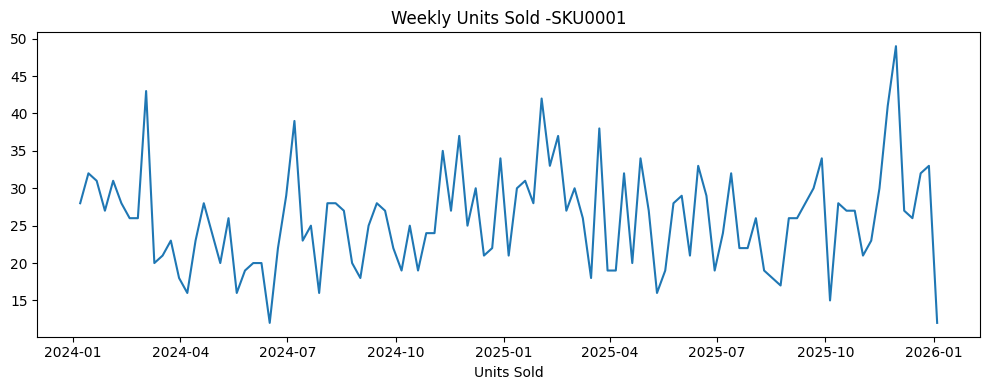

In [3]:
#Visualize it 
plt.figure(figsize=(10,4))
plt.plot(weekly["week_start"],weekly["units_sold"])
plt.title(f"Weekly Units Sold -{sample_sku}")
plt.xlabel("Units Sold")
plt.tight_layout()
plt.show()


In [4]:
weekly["seasonal_naive"] = weekly["units_sold"].shift(52)

weekly[["week_start","units_sold","seasonal_naive"]].tail(10)



,week_start,units_sold,seasonal_naive
95,2025-11-02,21.0,24.0
96,2025-11-09,23.0,35.0
97,2025-11-16,30.0,27.0
98,2025-11-23,41.0,37.0
99,2025-11-30,49.0,25.0
100,2025-12-07,27.0,30.0
101,2025-12-14,26.0,21.0
102,2025-12-21,32.0,22.0
103,2025-12-28,33.0,34.0
104,2026-01-04,12.0,21.0


In [5]:
def wape(actual,forecast):
    actual = actual.dropna()
    forecast = forecast.loc[actual.index]
    return (actual - forecast).abs().sum() / actual.sum() * 100

# Only evaluate where we actually have a baseline value (weeks 52 onward)
valid = weekly.dropna(subset=["seasonal_naive"])

baseline_wape = wape(valid["units_sold"], valid["seasonal_naive"])
print(f"Seasonal-naive baseline WAPE:{ baseline_wape:.1f}%")


Seasonal-naive baseline WAPE:25.0%


In [6]:
# Feature Engineering
model_df = weekly.copy()

# Lag Features: what did we sell in recent past weeks?
model_df["lag_1"] = model_df["units_sold"].shift(1)
model_df["lag_2"] = model_df["units_sold"].shift(2)
model_df["lag_52"] = model_df["units_sold"].shift(52) 

# Rolling average: smoothed recent trend
model_df['rolling_mean_4'] = model_df["units_sold"].shift(1).rolling(4).mean()

model_df[["week_start", "units_sold", "lag_1","lag_2","rolling_mean_4"]].tail(8)


,week_start,units_sold,lag_1,lag_2,rolling_mean_4
97,2025-11-16,30.0,23.0,21.0,24.50
98,2025-11-23,41.0,30.0,23.0,25.25
99,2025-11-30,49.0,41.0,30.0,28.75
100,2025-12-07,27.0,49.0,41.0,35.75
101,2025-12-14,26.0,27.0,49.0,36.75
102,2025-12-21,32.0,26.0,27.0,35.75
103,2025-12-28,33.0,32.0,26.0,33.50
104,2026-01-04,12.0,33.0,32.0,29.50


In [7]:
# Get season and promo info per week (from the daily data, take the most common value per week)
calender_features = df[df["sku_id"] == sample_sku].set_index("date")[["season","promo_flag"]]
calender_features = calender_features.resample("W").agg({
    "season": lambda x : x.mode()[0],          # most common season that week
    "promo_flag": "max"                        # 1 if any day that week was on promo
})

calender_features = calender_features.reset_index()
calender_features.columns = ["week_start","season","promo_flag"]

model_df = model_df.merge(calender_features, on="week_start", how="left")

# Convert season text into numbers the model can use (one-hot encoding)
model_df = pd.get_dummies(model_df, columns=["season"], drop_first=True)

model_df.tail(5)


,week_start,units_sold,seasonal_naive,lag_1,lag_2,lag_52,rolling_mean_4,promo_flag,season_Spring,season_Summer,season_Winter
100,2025-12-07,27.0,30.0,49.0,41.0,30.0,35.75,0,False,False,True
101,2025-12-14,26.0,21.0,27.0,49.0,21.0,36.75,0,False,False,True
102,2025-12-21,32.0,22.0,26.0,27.0,22.0,35.75,0,False,False,True
103,2025-12-28,33.0,34.0,32.0,26.0,34.0,33.50,0,False,False,True
104,2026-01-04,12.0,21.0,33.0,32.0,21.0,29.50,0,False,False,True


In [8]:
# Drop rows with any missing features values (mostly the first 52 weeeks)
clean_df = model_df.dropna().reset_index(drop=True)
print(f"Usable rows after dropping NaNs: {len(clean_df)}")

# Time-based split: train on earlier weeks, test on the most recent 10 weeks 
test_size = 10
train = clean_df.iloc[:-test_size]
test = clean_df.iloc[-test_size:]

print(f"Train weeks:{len(train)}, Test weeks: {len(test)}")
print(f"Test period: {test['week_start'].min().date()} to {test['week_start'].max().date()}")

Usable rows after dropping NaNs: 53
Train weeks:43, Test weeks: 10
Test period: 2025-11-02 to 2026-01-04


In [13]:
from sklearn.ensemble import RandomForestRegressor 

feature_cols = ["lag_1","lag_2","lag_52","rolling_mean_4","promo_flag",
                "season_Spring","season_Summer","season_Winter"]
X_train = train[feature_cols]
y_train = train["units_sold"]
X_test = test[feature_cols]
y_test  = test["units_sold"]

model = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
model.fit(X_train, y_train)

predictions = model.predict(X_test)
print("Predictions:", predictions.round(1))
print("Actual:      " ,y_test.values)


Predictions: [29.1 28.4 27.3 27.9 23.9 31.6 27.2 30.3 30.8 25.2]
Actual:       [21. 23. 30. 41. 49. 27. 26. 32. 33. 12.]


In [14]:
# Calculate the model's WAPE and compare to baseline

model_wape = wape(pd.Series(y_test.values), pd.Series(predictions))
print(f"Baseline (seasonal-naive) WAPE: {baseline_wape:.1f}%")
print(f"Model (Random Forest) WAPE: {model_wape:.1f}%")

if model_wape < baseline_wape:
    print(f"\n Model beats baseline by {baseline_wape - model_wape:>1f} percentage points")
else:
    print(f"\n Model does NOT beat baseline (worse by {model_wape - baseline_wape:.1f} points)")



Baseline (seasonal-naive) WAPE: 25.0%
Model (Random Forest) WAPE: 26.4%

 Model does NOT beat baseline (worse by 1.4 points)


In [15]:
# Aggregate all SKUs to weekly level(not just one SKU this time )
all_weekly = df.set_index("date").groupby("sku_id").resample("W")["units_sold"].sum().reset_index()

print(f"Total rows(SKUs * weeks): {len(all_weekly)}")
all_weekly.head()


Total rows(SKUs * weeks): 21000


,sku_id,date,units_sold
0,SKU0001,2024-01-07,28.0
1,SKU0001,2024-01-14,32.0
2,SKU0001,2024-01-21,31.0
3,SKU0001,2024-01-28,27.0
4,SKU0001,2024-02-04,31.0


In [17]:
# Rebuild features for all SKUs

all_weekly = all_weekly.sort_values(["sku_id","date"]).reset_index(drop=True)

# IMPORTANT: group by sku_id so lag/rolling features don't leak across different products
all_weekly["lag_1"] = all_weekly.groupby("sku_id")["units_sold"].shift(1)
all_weekly["lag_2"] = all_weekly.groupby("sku_id")["units_sold"].shift(2)
all_weekly["lag_52"] = all_weekly.groupby("sku_id")["units_sold"].shift(52)
all_weekly["rolling_mean_4"] = all_weekly.groupby("sku_id")["units_sold"].shift(1).rolling(4).mean()
all_weekly["seasonal_naive"] = all_weekly.groupby("sku_id")["units_sold"].shift(52)

all_weekly.head(5)


,sku_id,date,units_sold,lag_1,lag_2,lag_52,rolling_mean_4,seasonal_naive
0,SKU0001,2024-01-07,28.0,NaN,NaN,NaN,NaN,NaN
1,SKU0001,2024-01-14,32.0,28.0,NaN,NaN,NaN,NaN
2,SKU0001,2024-01-21,31.0,32.0,28.0,NaN,NaN,NaN
3,SKU0001,2024-01-28,27.0,31.0,32.0,NaN,NaN,NaN
4,SKU0001,2024-02-04,31.0,27.0,31.0,NaN,29.5,NaN


In [21]:
calender_features_all = df.set_index("date").groupby("sku_id").resample("W").agg({
    "season" : lambda x: x.mode()[0],
    "promo_flag" : "max",
    "category": "first"
}).reset_index()

all_weekly = all_weekly.merge(
    calender_features_all[["sku_id", "date", "season", "promo_flag", "category"]],
    on=["sku_id","date"], how="left"
)

all_weekly = pd.get_dummies(all_weekly,columns=["season","category"], drop_first=True)

print(all_weekly.shape)
all_weekly.columns.tolist()


(21000, 15)


['sku_id',
 'date',
 'units_sold',
 'lag_1',
 'lag_2',
 'lag_52',
 'rolling_mean_4',
 'seasonal_naive',
 'promo_flag',
 'season_Spring',
 'season_Summer',
 'season_Winter',
 'category_Bedding',
 'category_Decor',
 'category_Furniture']

In [23]:
# Drop incomplete rows, split by time , train the pooled model 

clean_all = all_weekly.dropna().reset_index(drop=True)
print(f"Usable rows after dropping NaNs: {len(clean_all)}")

# Time-based split: last 10 weeks per SKU are the test set 
clean_all = clean_all.sort_values(["sku_id","date"])
test_all = clean_all.groupby("sku_id").tail(10)
train_all = clean_all.drop(test_all.index)

print(f"Train rows: {len(train_all)}, Test rows:{len(test_all)}")


Usable rows after dropping NaNs: 10600
Train rows: 8600, Test rows:2000


In [26]:
feature_cols_all = ["lag_1","lag_2","lag_52","rolling_mean_4","promo_flag",
                    "season_Spring","season_Summer","season_Winter",
                    "category_Bedding","category_Decor","category_Furniture"]

X_train_all = train_all[feature_cols_all]
y_train_all = train_all["units_sold"]
X_test_all = test_all[feature_cols_all]
y_test_all = test_all["units_sold"]

model_all = RandomForestRegressor(n_estimators=300 , max_depth=8, random_state=42)
model_all.fit(X_train_all, y_train_all)

predictions_all = model_all.predict(X_test_all)

baseline_wape_all = wape(pd.Series(y_test_all.values),pd.Series(test_all["seasonal_naive"].values))
model_wape_all = wape(pd.Series(y_test_all.values), pd.Series(predictions_all))

print(f"Baseline (seasonal-naive) WAPE: {baseline_wape_all:.1f}%")
print(f"Model (Random Forest ) WAPE : {model_wape_all:.1f}%")

if model_wape_all < baseline_wape_all:
    print(f"\n Model beats baseline by {baseline_wape_all - model_wape_all:.1f} percentage points")
else:
    print(f"\n Model does NOT beat baseline (worse by {model_wape_all - baseline_wape_all:.1f} points )")



Baseline (seasonal-naive) WAPE: 21.9%
Model (Random Forest ) WAPE : 22.1%

 Model does NOT beat baseline (worse by 0.3 points )


In [27]:
all_weekly["rolling_mean_8"] = all_weekly.groupby("sku_id")["units_sold"].shift(1).rolling(8).mean()
all_weekly["sku_avg_demand"] = all_weekly.groupby("sku_id")["units_sold"].transform(
    lambda x: x.shift(1).expanding().mean()
)

clean_all = all_weekly.dropna().reset_index(drop=True)
clean_all = clean_all.sort_values(["sku_id", "date"])
test_all = clean_all.groupby("sku_id").tail(10)
train_all = clean_all.drop(test_all.index)

feature_cols_all = ["lag_1", "lag_2", "lag_52", "rolling_mean_4", "rolling_mean_8",
                     "sku_avg_demand", "promo_flag",
                     "season_Spring", "season_Summer", "season_Winter",
                     "category_Bedding", "category_Decor", "category_Furniture"]

X_train_all = train_all[feature_cols_all]
y_train_all = train_all["units_sold"]
X_test_all = test_all[feature_cols_all]
y_test_all = test_all["units_sold"]

model_all = RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42)
model_all.fit(X_train_all, y_train_all)
predictions_all = model_all.predict(X_test_all)

baseline_wape_all = wape(pd.Series(y_test_all.values), pd.Series(test_all["seasonal_naive"].values))
model_wape_all = wape(pd.Series(y_test_all.values), pd.Series(predictions_all))

print(f"Baseline WAPE: {baseline_wape_all:.1f}%")
print(f"Model WAPE:    {model_wape_all:.1f}%")

Baseline WAPE: 21.9%
Model WAPE:    20.5%
